In [56]:
import networkx as nx
import matplotlib.pyplot as plt
import random
import pennylane as qp
from pennylane import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import clear_output
import pandas as pd
import json
from datetime import datetime, time
import time

Note: see the project instructions for notations ($L$, $H_G$, etc.)

In [94]:
num_qubits = num_nodes = 7
L = 2
N_PARAMS_PER_LAYER = 2

DATASET_SIZE = 500
TEST_SIZE = 0.2

EPOCHS = 50
STEP_SIZE = 0.1
SEED = 10101010
random.seed(SEED)
np.random.seed(SEED)

dev = qp.device("default.qubit", wires=num_qubits)

In [95]:
config = {
    "experiment_name": "unparametrized_filtereddataset",
    "num_nodes": num_nodes,
    "num_layers": L,
    "num_params_per_layer": N_PARAMS_PER_LAYER,
    "parameterized_encoding": True,
    "dataset_size": DATASET_SIZE,
    "test_size": TEST_SIZE,
    "step_size": STEP_SIZE,
    "epochs": EPOCHS,
    "seed": SEED
}

### Parametrized Quantum Circuit

In [96]:
def data_encoding_circuit_block(ising_hamiltonian):
    qp.exp(ising_hamiltonian, coeff=1j)

def variational_layer(theta):
    for i in range(num_qubits):
        qp.RX(theta[0], wires=i)
        if len(theta) >= 2:
            qp.RY(theta[1], wires=i)
        if len(theta) >= 3:
            qp.RZ(theta[2], wires=i)

@qp.qnode(dev)
def pqc(theta_params, H_G):
    for i in range(num_qubits):
        qp.Hadamard(wires=i)
    for j in range(L):
        data_encoding_circuit_block(H_G)    # M
        variational_layer(theta_params[j])     # W_j

    return qp.probs(wires=range(num_qubits))

### Metrics

In [97]:
def bce_loss(theta_params, H_G, y):
    """'Computes the BCE loss between the prediction of the PQC (given the current theta_params and the graph encoding H_G) and the true label"""
    probs = pqc(theta_params, H_G)
    prediction = probs[0]                             # h_k(M)

    eps = 1e-15
    pred_clipped = qp.math.clip(prediction, eps, 1.0 - eps)

    return -(y * qp.math.log(pred_clipped) + (1 - y) * qp.math.log(1 - pred_clipped))

def cost_function(theta_params, dataset=None):
    """Computes the mean of all BCE losses over a given dataset"""
    losses = []

    for _, H_G, y in dataset:
        loss_value = bce_loss(theta_params, H_G, y)
        losses.append(loss_value)

    return qp.math.mean(qp.math.stack(losses))

def compute_accuracy(theta_params, dataset=None):
    """Computes the accuracy of the PQC (proportion of correct predictions) on a given dataset"""
    correct_predictions = 0

    for _, H_G, y in dataset:
        probs = pqc(theta_params, H_G)
        prediction = probs[0]

        discrete_pred = 1 if prediction >= 0.5 else 0
        if discrete_pred == y:
            correct_predictions += 1

    return correct_predictions / len(dataset)

### Utils

In [98]:
def get_ising_hamiltonian(adj_matrix):
    """
    Returns the Ising Hamiltonian for a given adjacency matrix, as defined in the project instructions.
    If the graph has no edges, returns the zero Hamiltonian.
    """
    n = adj_matrix.shape[0]
    coeffs = []
    obs = []
    for i in range(n):
        for j in range(i + 1, n):
            if adj_matrix[i, j] == 1:
                coeffs.append(1.)
                obs.append(qp.PauliZ(i) @ qp.PauliZ(j))
    if len(obs) == 0:
        return qp.Hamiltonian([0.0], [qp.Identity(0)])
    return qp.Hamiltonian(coeffs, obs)

### Data Generation

In [99]:
dataset = []

threshold = np.log(num_nodes) / num_nodes   # The theoretical threshold for a graph to be connected is ln(n)/n
edge_probabilities = [random.uniform(threshold*0.9, threshold*1.5) for _ in range(DATASET_SIZE)]

connected_count = 0
disconnected_count = 0
for p in edge_probabilities:
    G = nx.erdos_renyi_graph(n=num_nodes, p=p)
    A = nx.to_numpy_array(G)
    H_G = get_ising_hamiltonian(A)
    if nx.is_connected(G):
        y = 0
        connected_count+=1
    else:
        y = 1
        disconnected_count+=1
    dataset.append((A, H_G, y))
config["connected_ratio"] = connected_count / len(dataset)

print(f"The full dataset contains {connected_count} connected graphs and {disconnected_count} disconnected graphs.")
train_data, test_data = train_test_split(dataset, test_size=TEST_SIZE, random_state=SEED)

The full dataset contains 249 connected graphs and 251 disconnected graphs.


In [100]:
def filter_isomorphisms(source_dataset):
    """
    Filters a dataset to contain only non-isomorphic graphs.
    If reference_graphs is provided, it also ensures no graph in the
    source_dataset is isomorphic to any graph in the reference_graphs.
    """

    unique_graphs = list()
    filtered_dataset = []

    for data_point in source_dataset:
        A, H_G, y = data_point
        G_current = nx.from_numpy_array(A)

        is_iso = False
        for G_seen in unique_graphs:
            if nx.is_isomorphic(G_current, G_seen):
                is_iso = True
                break

        if not is_iso:
            unique_graphs.append(G_current)
            filtered_dataset.append(data_point)

    return filtered_dataset

print(f"Original train size: {len(train_data)}")
train_data_clean = filter_isomorphisms(train_data)
print(f"Cleaned train size (no internal isomorphisms): {len(train_data_clean)}\n")

train_data = train_data_clean

Original train size: 400
Cleaned train size (no internal isomorphisms): 224



If the cell below is run, the training data set will be replaced by the entire set of non-isomorphic graphs of $G_{\text{num\_nodes}}$. Only tenable for $\text{num\_nodes} \leq 7$.

In [241]:
all_atlas_graphs = nx.graph_atlas_g()       # contains all non-isomorphic graphs up to 7 nodes

non_isomorphic_graphs = [G for G in all_atlas_graphs if G.number_of_nodes() == num_nodes]
print(f"Generated {len(non_isomorphic_graphs)} non-isomorphic graphs for n={num_nodes}.")

train_data = []
connected_train_count = 0

for G in non_isomorphic_graphs:
    A = nx.to_numpy_array(G)
    H_G = get_ising_hamiltonian(A)

    if nx.is_connected(G):
        y = 0
        connected_train_count += 1
    else:
        y = 1

    train_data.append((A, H_G, y))

disconnected_train_count = len(train_data) - connected_train_count
print(f"Train dataset: {connected_train_count} connected | {disconnected_train_count} disconnected.")


test_data = []
connected_test_count = 0

for _ in range(20):
    base_G = random.choice(non_isomorphic_graphs)

    nodes = list(base_G.nodes())
    shuffled_nodes = nodes.copy()
    random.shuffle(shuffled_nodes)
    mapping = dict(zip(nodes, shuffled_nodes))

    permuted_G = nx.relabel_nodes(base_G, mapping)

    A_perm = nx.to_numpy_array(permuted_G)
    H_G_perm = get_ising_hamiltonian(A_perm)

    if nx.is_connected(permuted_G):
        y = 0
        connected_test_count += 1
    else:
        y = 1

    test_data.append((A_perm, H_G_perm, y))

disconnected_test_count = len(test_data) - connected_test_count
print(f"Test dataset: {connected_test_count} connected | {disconnected_test_count} disconnected.")

Generated 1044 non-isomorphic graphs for n=7.
Train dataset: 853 connected | 191 disconnected.
Test dataset: 14 connected | 6 disconnected.


### Training

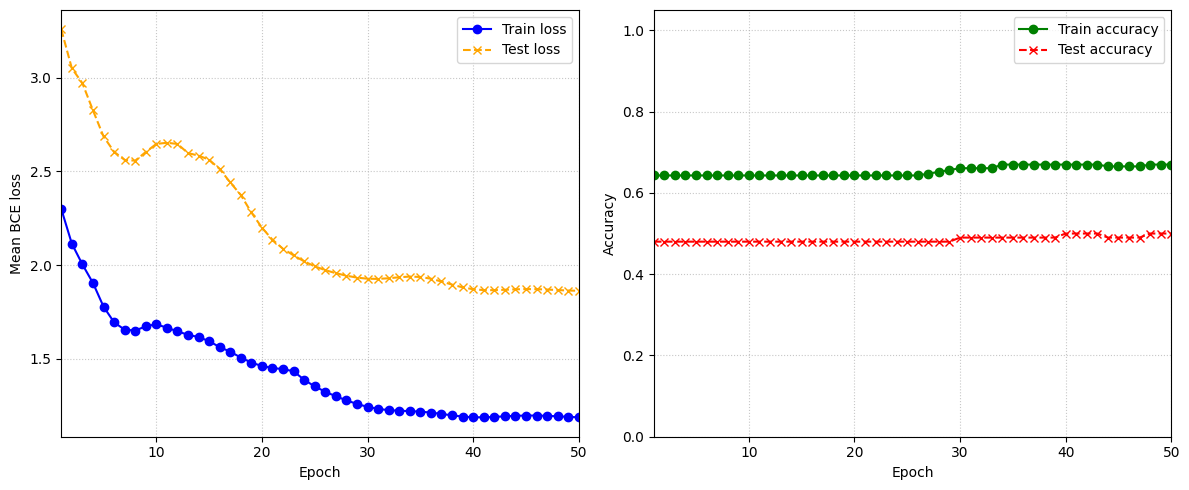

Epoch  50 / 50 | Train Loss: 1.1862 | Train Acc: 0.67 | Test Loss: 1.8624 | Test Acc: 0.50 | Epoch Time: 6.87 sec

Final Optimized Parameters (thetas): [[ 2.02057353 -0.11732419]
 [ 1.97921225  4.77093929]]


In [101]:
thetas = np.random.uniform(0, 2*np.pi, size=(L, N_PARAMS_PER_LAYER), requires_grad=True)

opt = qp.AdamOptimizer(stepsize=STEP_SIZE)

history_train_loss = []
history_test_loss = []
history_train_acc = []
history_test_acc = []

print("Starting Training...")

total_start_time = time.time()
epoch_times = []

for epoch in range(EPOCHS):
    epoch_start_time = time.time()

    cost_function_train = lambda t: cost_function(t, dataset=train_data)
    thetas = opt.step(cost_function_train, thetas)

    train_loss = cost_function(thetas, dataset=train_data)
    train_acc = compute_accuracy(thetas, dataset=train_data)
    test_loss = cost_function(thetas, dataset=test_data)
    test_acc = compute_accuracy(thetas, dataset=test_data)

    history_train_loss.append(train_loss)
    history_test_loss.append(test_loss)
    history_train_acc.append(train_acc)
    history_test_acc.append(test_acc)

    clear_output(wait=True)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epoch + 2), history_train_loss, label='Train loss', marker='o', color='blue')
    plt.plot(range(1, epoch + 2), history_test_loss, label='Test loss', marker='x', linestyle='--', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Mean BCE loss')
    plt.xlim(1, EPOCHS)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epoch + 2), history_train_acc, label='Train accuracy', marker='o', color='green')
    plt.plot(range(1, epoch + 2), history_test_acc, label='Test accuracy', marker='x', linestyle='--', color='red')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.xlim(1, EPOCHS)
    plt.ylim(0.0, 1.05)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

    plt.tight_layout()
    plt.show()

    epoch_end_time = time.time()
    epoch_duration = epoch_end_time - epoch_start_time
    epoch_times.append(epoch_duration)

    print(f"Epoch {epoch + 1:3d} / {EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f} | "
          f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f} | "
          f"Epoch Time: {epoch_duration:.2f} sec")

total_end_time = time.time()
total_duration = total_end_time - total_start_time

print("\nFinal Optimized Parameters (thetas):", thetas)

 ### Confusion Matrix

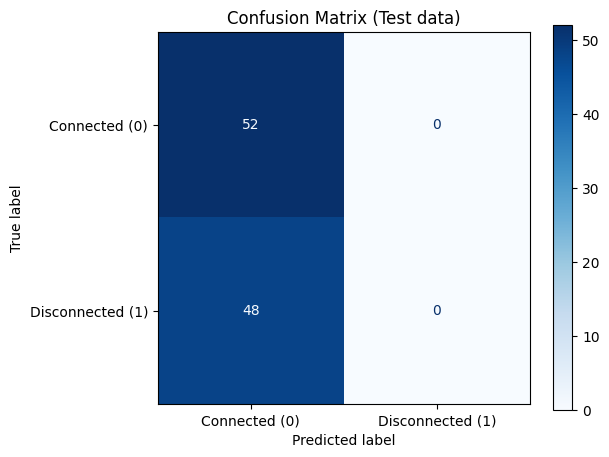

In [74]:
true_labels = []
predicted_labels = []

for A_i, H_i, y_i in test_data:
    true_labels.append(y_i)

    probs = pqc(thetas, H_i)
    prediction = probs[0]

    discrete_pred = 1 if prediction >= 0.5 else 0
    predicted_labels.append(discrete_pred)

cm = confusion_matrix(true_labels, predicted_labels, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Connected (0)', 'Disconnected (1)']
)

disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix (Test data)')
plt.show()

In [102]:
results = {
    **config,
    "final_train_loss": round(float(history_train_loss[-1]), 3),
    "final_test_loss": round(float(history_test_loss[-1]), 3),
    "final_train_acc": round(float(history_train_acc[-1]), 3),
    "final_test_acc": round(float(history_test_acc[-1]), 3),
    "total_training_time_sec": round(total_duration, 2),
    "avg_time_per_epoch_sec": round(np.mean(epoch_times), 2),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
}

with open("experiments_log.jsonl", "a") as f:
    f.write(json.dumps(results) + "\n")